# 02 — Commits by Time of Day: Stacked Bar Chart

## What this notebook does

Analyzes when during the day students were most active by categorizing
each checker submission into one of four time periods and visualizing
the distribution as a stacked bar chart.

## Data

- **Source:** `checking-logs.sqlite` → table `checker`
- **Filtered:** only real students (`uid LIKE 'user_%'`)
- **Aggregation:** commit counts grouped by date and time of day

## Key steps

1. Query checker timestamps with a SQL `CASE` statement that buckets
   each submission into `night` (00–03), `morning` (04–09),
   `afternoon` (10–16), or `evening` (17–23)
2. Pivot the result so each time period becomes a column
3. Fill missing values with `0`
4. Plot a stacked bar chart with custom colors per time period

## Result

A stacked bar chart showing daily commit volume broken down by time of day.
Evening submissions consistently competed with afternoon ones —
the busiest single day was **2020-05-12**, where evening activity
exceeded afternoon.

## Tools

`pandas` · `sqlite3` · `matplotlib`

In [11]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../data/checking-logs.sqlite')

In [12]:
day_n_daytime = pd.io.sql.read_sql("""
                                   SELECT date(c.timestamp) AS date, 
                                   CASE
                                   WHEN strftime("%H", c.timestamp) BETWEEN '00' AND '03' THEN 'night'
                                   WHEN strftime('%H', c.timestamp) BETWEEN '04' AND '09' THEN 'morning'
                                   WHEN strftime('%H', c.timestamp) BETWEEN '10' AND '16' THEN 'afternoon'
                                   ELSE 'evening'
                                   END AS daytime,
                                   COUNT(*) AS count
                                   FROM checker AS c
                                   WHERE c.uid LIKE 'user_%'
                                   GROUP BY date, daytime
                                   """, conn)
day_n_daytime

,date,daytime,count
0,2020-04-17,afternoon,10
1,2020-04-17,morning,13
2,2020-04-18,afternoon,33
3,2020-04-18,evening,35
4,2020-04-18,morning,1
...,...,...,...
85,2020-05-20,evening,10
86,2020-05-20,morning,7
87,2020-05-21,afternoon,27
88,2020-05-21,evening,21


In [13]:
pivot_day_n_daytime = day_n_daytime.pivot(index='date', columns='daytime', values='count')
pivot_day_n_daytime.head()

daytime,afternoon,evening,morning,night
date,,,,
2020-04-17,10.0,NaN,13.0,NaN
2020-04-18,33.0,35.0,1.0,NaN
2020-04-19,16.0,11.0,4.0,2.0
2020-04-20,12.0,13.0,NaN,NaN
2020-04-21,NaN,25.0,NaN,NaN


In [14]:
pivot_day_n_daytime = pivot_day_n_daytime.fillna(0)
pivot_day_n_daytime.isnull().sum()
print(len(pivot_day_n_daytime))

35


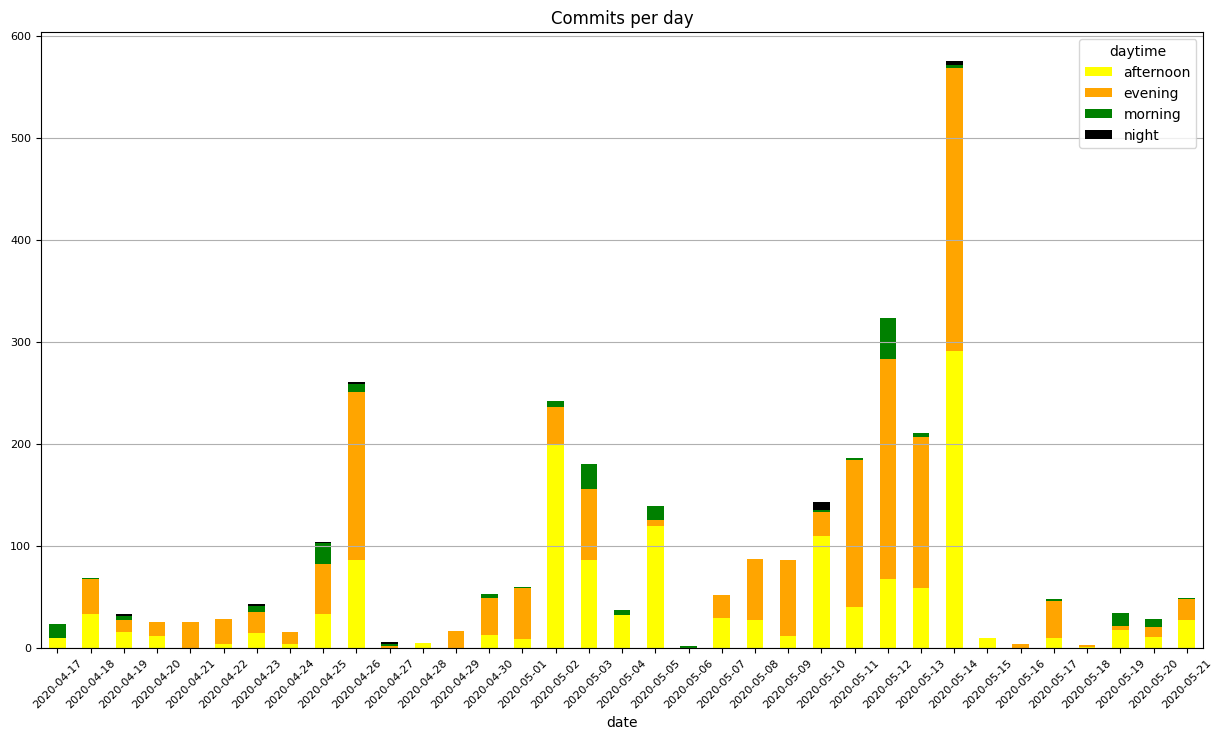

In [15]:
ax = pivot_day_n_daytime.plot(
    kind='bar', 
    stacked=True, 
    figsize=(15,8), 
    fontsize=8, 
    rot=45, 
    title='Commits per day', 
    color=['yellow', 'orange', 'green', 'black']
)
ax.yaxis.grid(True)

In [16]:
pivot_day_n_daytime.sum()

daytime
afternoon    1391.0
evening      1611.0
morning       184.0
night          21.0
dtype: float64

In [17]:
pivot_day_n_daytime['total'] = pivot_day_n_daytime.sum(axis=1)
filtered = pivot_day_n_daytime[pivot_day_n_daytime['evening'] > pivot_day_n_daytime['afternoon']]
filtered.sort_values('total', ascending=False).head(1)


daytime,afternoon,evening,morning,night,total
date,,,,,
2020-05-12,68.0,215.0,40.0,0.0,323.0


In [18]:
conn.close()

evening, afternoon

2020-05-12